In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")
import helper_functions as hf
import qRegNN_NFs_general as qrnn
import qRegNN_NFs_general_allInOne as qrnn2
import sklearn
import scipy
import sklearn.datasets as datasets
import h5py
import os
import pandas as pd
import corner
from sklearn.model_selection import train_test_split
sys.path.append("/home/sambt/SINF/")
sys.path.append("/home/sambt/SINF/sinf/")
from GIS import GIS
import torch
import torch.nn as nn
device = torch.device('cuda:0')
import uproot
from tqdm import tqdm
import h5py

In [2]:
base = "/nobackup/users/sambt/QR_samples/LHCO/"
f_bb1 = f"{base}/challenge/BB1/merged.h5"
f_ind_bb1 = f"{base}/challenge/BB1/split_indices.h5"
f_rd = f"{base}/rd/RD/merged.h5"
f_ind_rd = f"{base}/rd/RD/split_indices.h5"


fitvars = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43',
           'jet1_pt','jet1_eta','jet1_phi']

with h5py.File(f_ind_rd,'r') as f:
    rd_test_idx = f['test_inds'][()]
    
with h5py.File(f_ind_bb1,'r') as f:
    bb1_test_idx = f['test_inds'][()]
    
with h5py.File(f_bb1,"r") as fp_b1:
    labels_b1 = np.loadtxt(f"{base}/challenge/BB1/events_LHCO2020_BlackBox1.masterkey")
    b1 = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_test_idx]
    
with h5py.File(f_rd,"r") as frd:
    label = frd['label'][()]
    mask = label==0
    rd = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_test_idx]
    
fb1 = "/nobackup/users/sambt/QR_samples/LHCO/contrastive/bb1_bkg_latent.h5"
with h5py.File(fb1,'r') as f:
    b1_sup = f['base_score'][()]
    
frd = "/nobackup/users/sambt/QR_samples/LHCO/contrastive/rd_bkg_latent.h5"
with h5py.File(frd,'r') as f:
    rd_sup = f['base_score'][()]
    
rd = np.concatenate((rd,rd_sup.reshape(-1,1)),axis=1)
b1 = np.concatenate((b1,b1_sup.reshape(-1,1)),axis=1)

rd_train, rd_test = train_test_split(rd,train_size=0.75)
b1_train, b1_test = train_test_split(b1,train_size=0.75)
fitvars = fitvars+['pn_score']

# Train flows

In [3]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":15,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
rangeScale = 3
variables = fitvars
trainer = qrnn.chainedNFTrainer("LHCO_PNTagger_BB1toRD_jet1plusKin",
                                b1_train,b1_test,rd_train,rd_test,fitvars,control=[],
                                NF_kwargs=NF_kwargs,rangeScale=rangeScale,separateScale=False)

## jet1 rho

Training flow bkgFlow_step0_jet1_rho


Loss: 1.3421605944633483, p = 24: 100%|██████████| 374/374 [01:28<00:00,  4.22it/s]


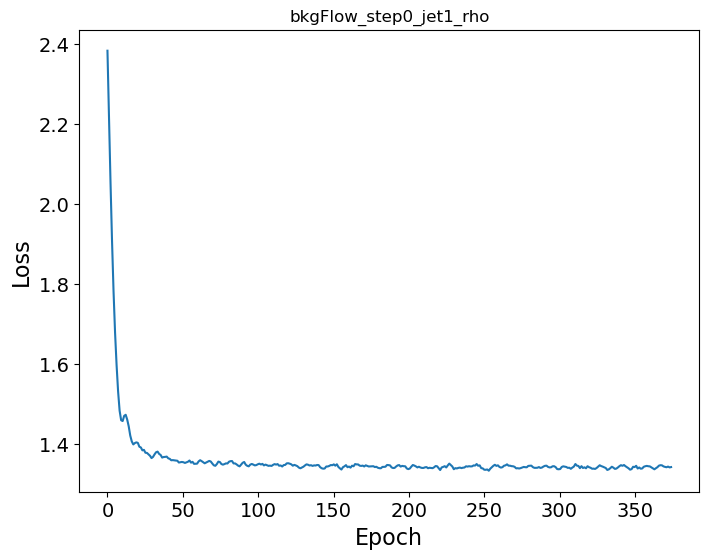

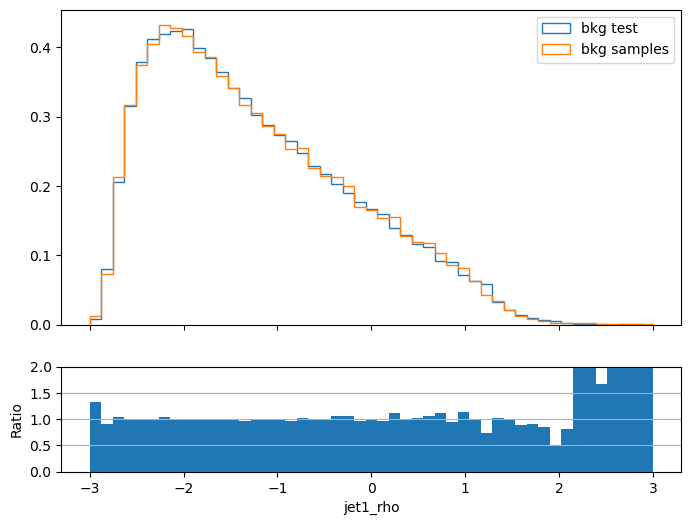

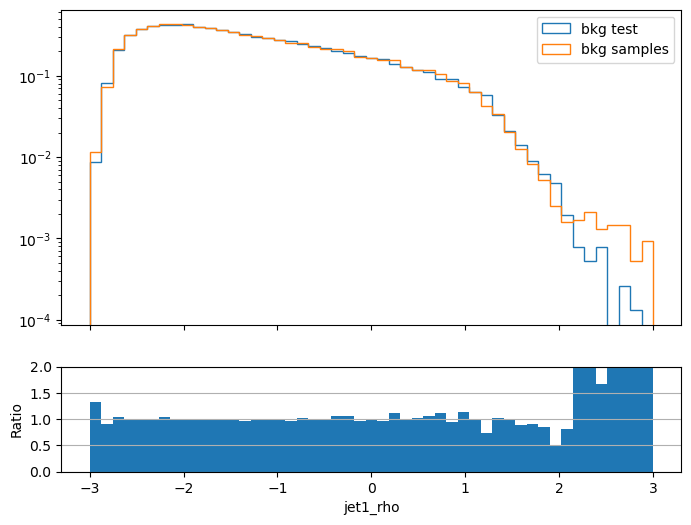

In [7]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True,ylim=[0,2])

Training flow dataFlow_step0_jet1_rho


Loss: 1.2887617933750153, p = 10: 100%|██████████| 375/375 [01:29<00:00,  4.19it/s]


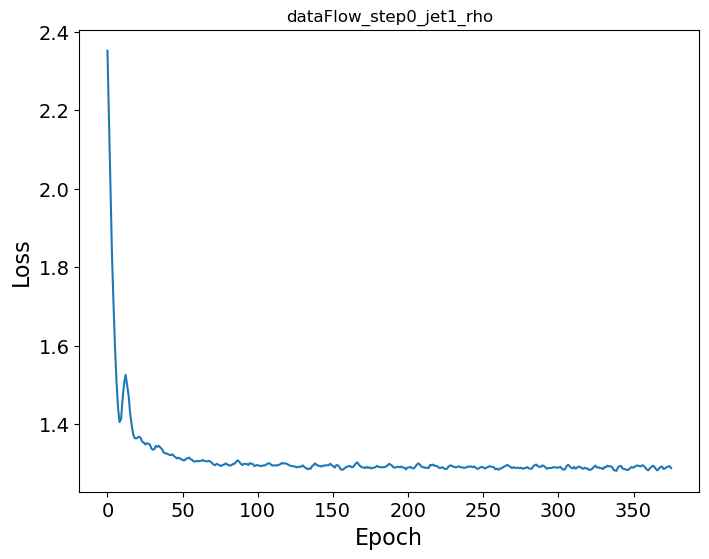

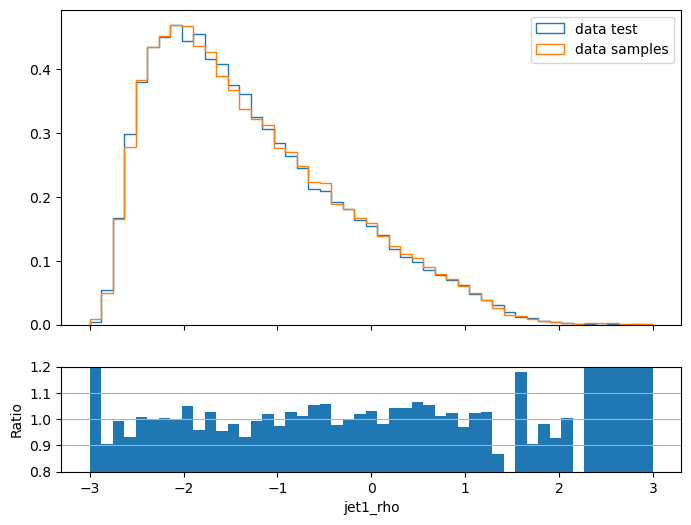

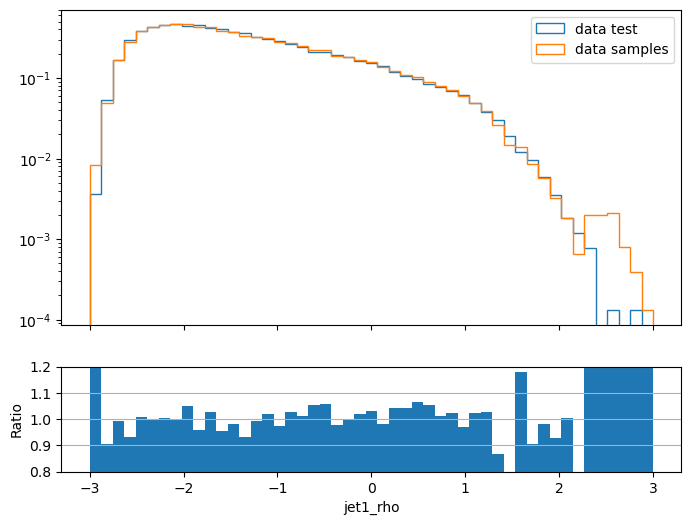

In [8]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 7/7 [00:00<00:00, 12.72it/s]


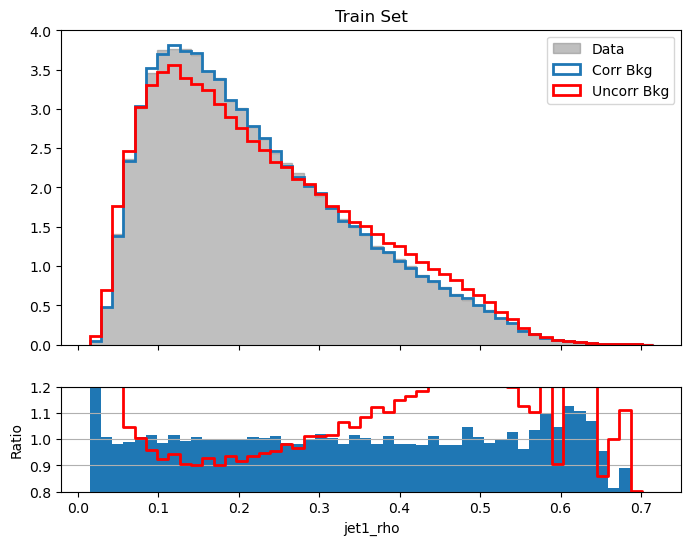

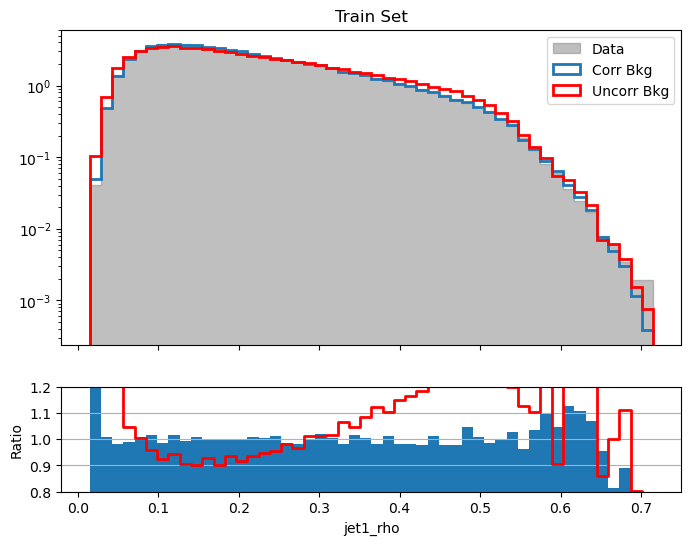

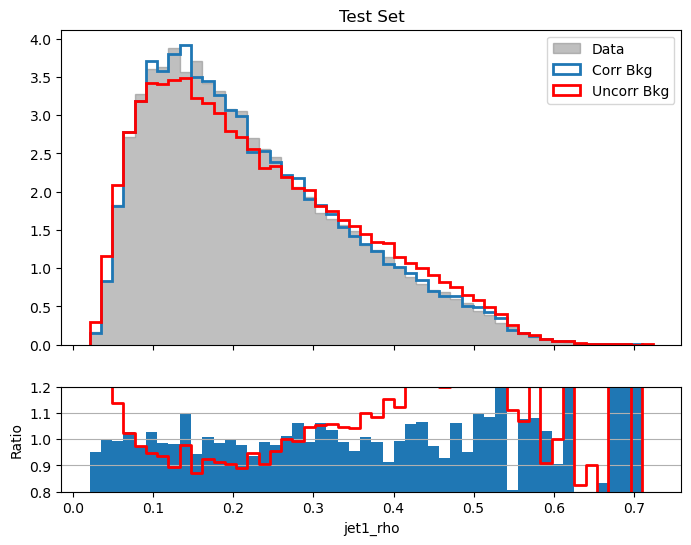

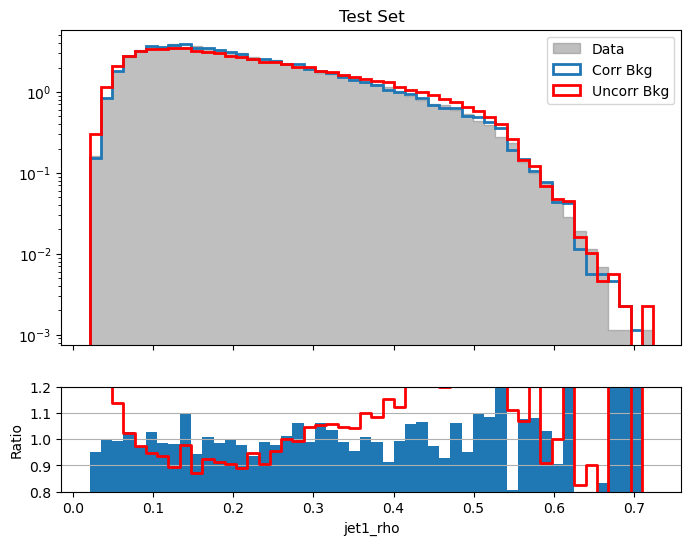

In [9]:
trainer.correctCurrent()
trainer.plotCurrent(50)

In [10]:
trainer.stepForward()

## jet1 tau21

Training flow bkgFlow_step1_jet1_tau21


Loss: 1.4437085390090942, p = 17: 100%|██████████| 93/93 [00:22<00:00,  4.12it/s]


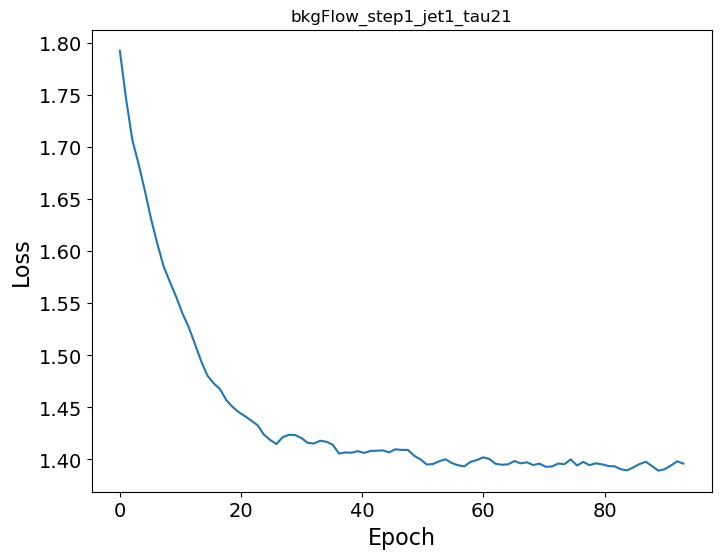

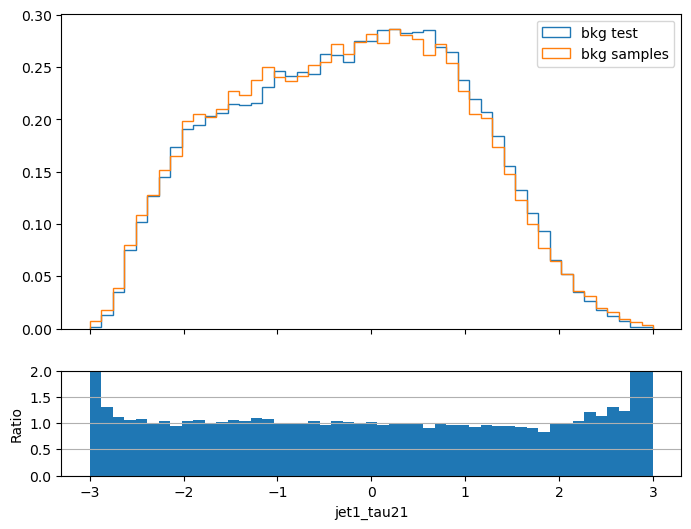

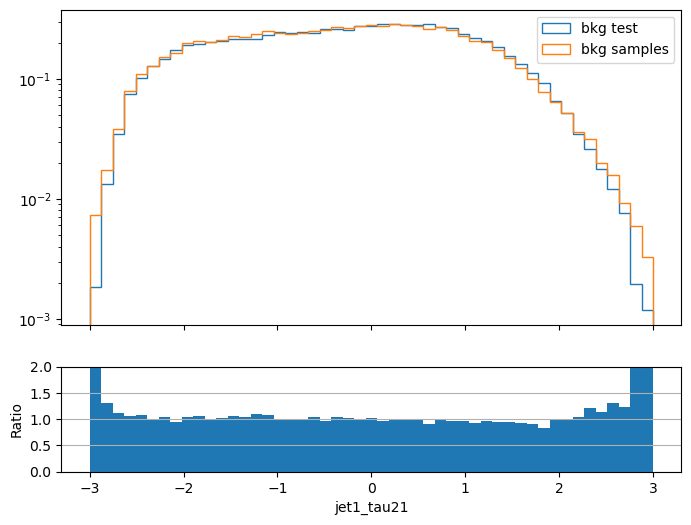

In [11]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 5
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True,ylim=[0,2])

Training flow dataFlow_step1_jet1_tau21


Loss: 1.3695393157005311, p = 4: 100%|██████████| 187/187 [00:45<00:00,  4.15it/s] 


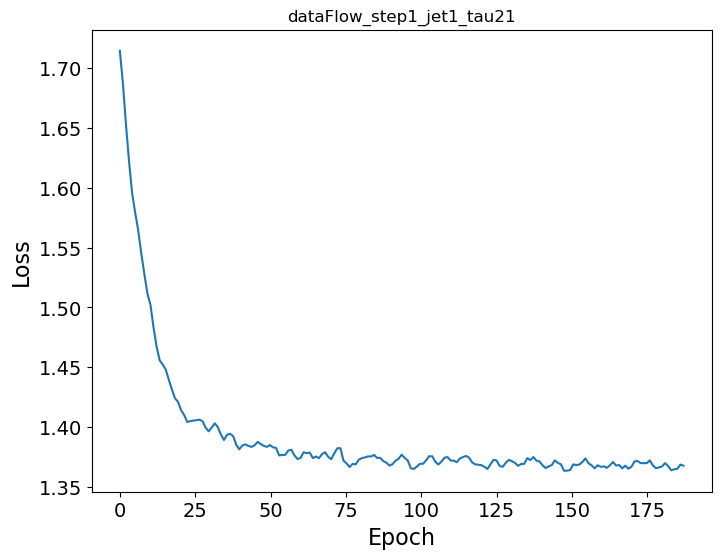

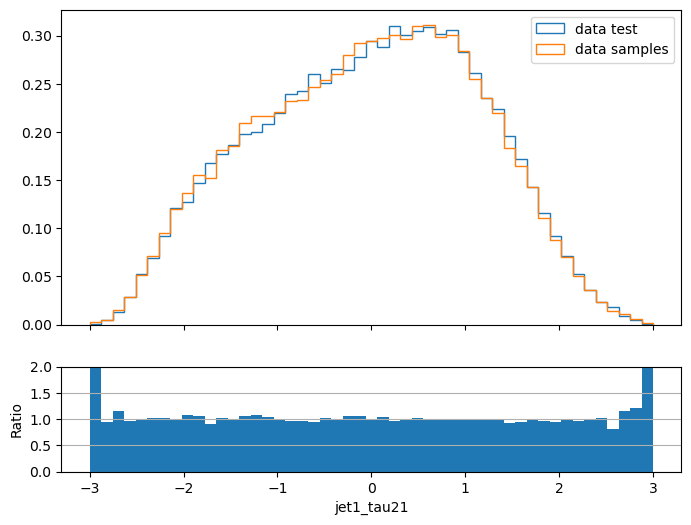

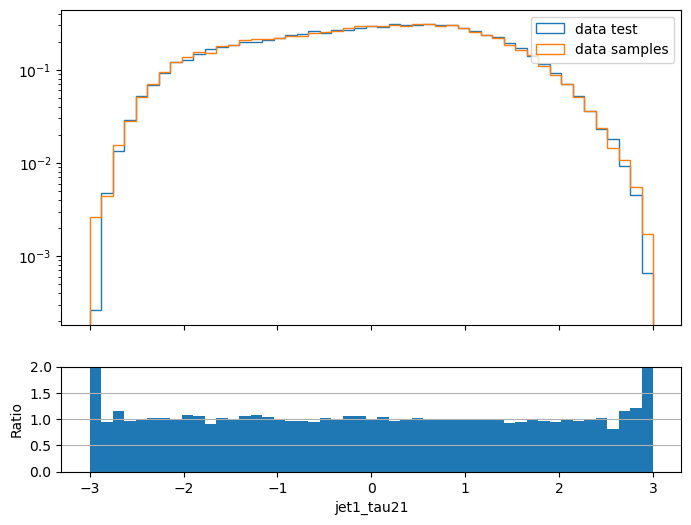

In [12]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 10
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True,ylim=[0,2])

100%|██████████| 7/7 [00:00<00:00, 12.70it/s]


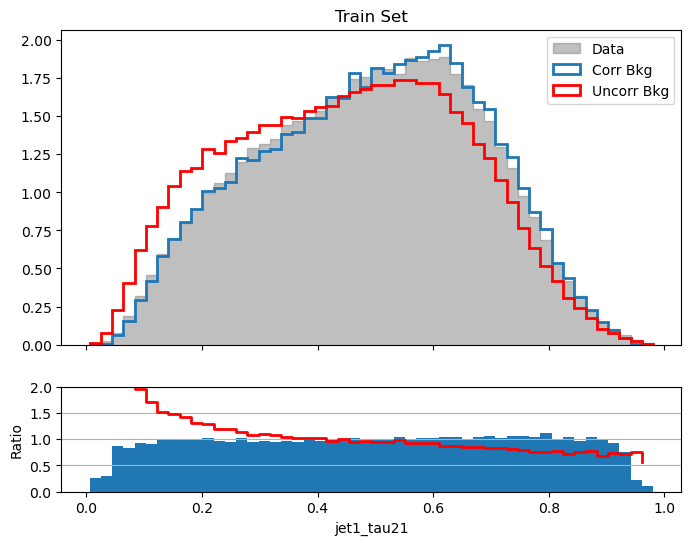

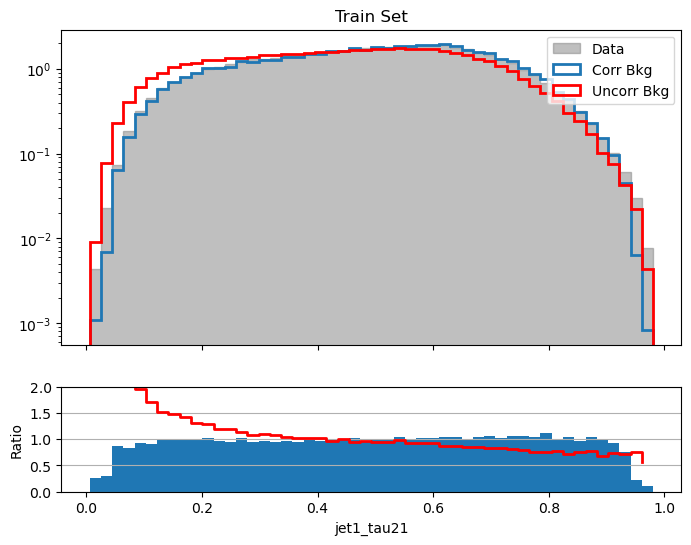

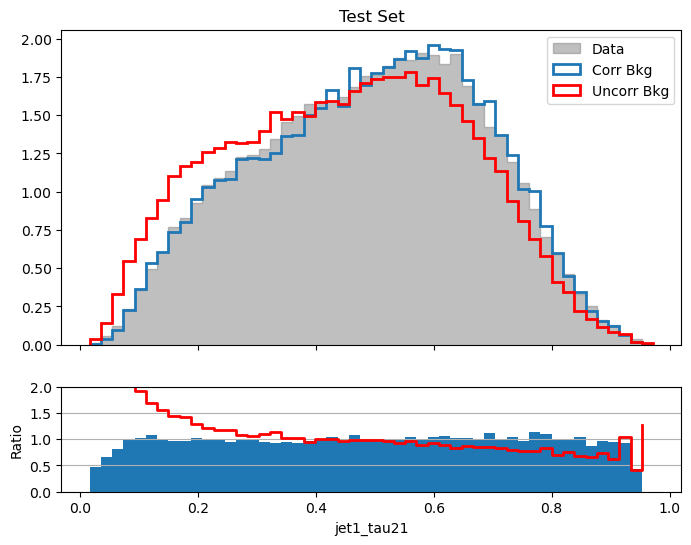

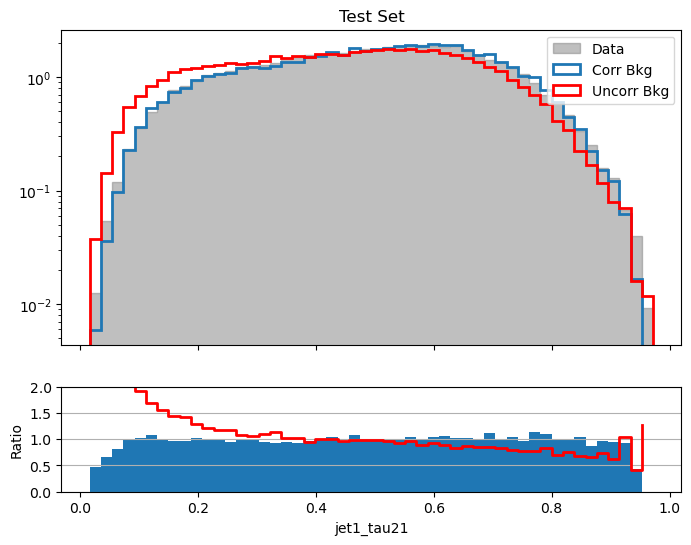

In [13]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [14]:
trainer.stepForward()

## jet1 tau32

Training flow bkgFlow_step2_jet1_tau32


Loss: 0.9814251166582107, p = 450: 100%|██████████| 914/914 [02:02<00:00,  7.45it/s]


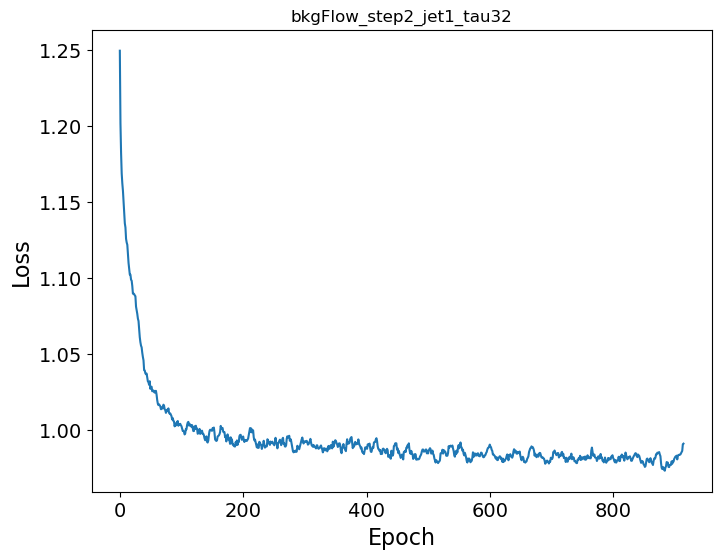

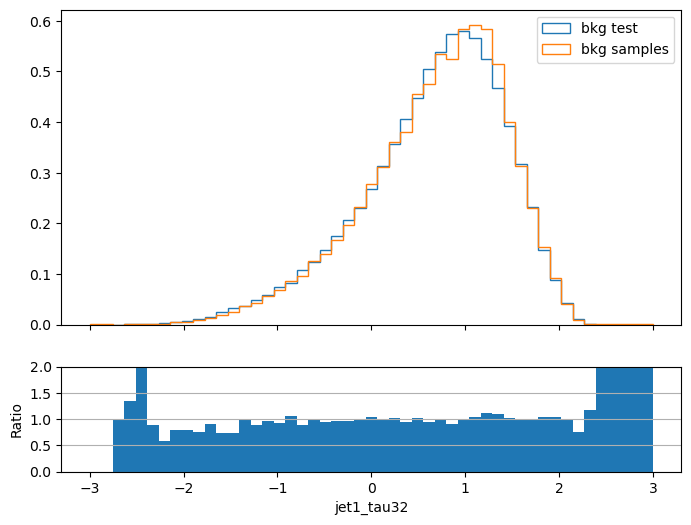

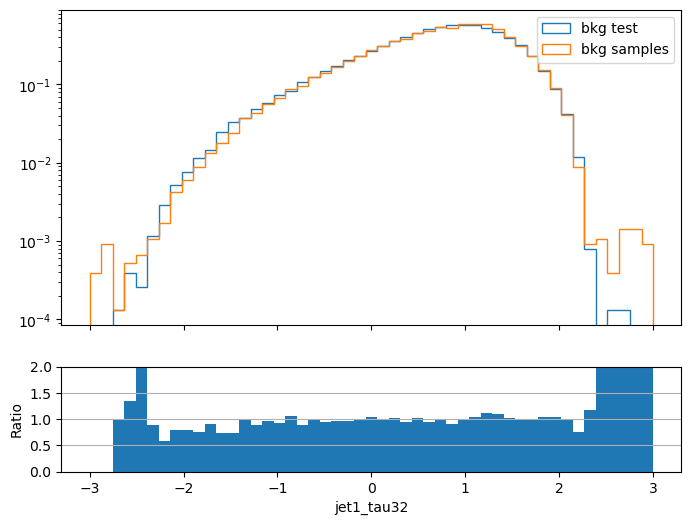

In [16]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 4096
n_epoch = 20
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True,ylim=[0,2])

Training flow dataFlow_step2_jet1_tau32


Loss: 0.92006416618824, p = 233: 100%|██████████| 915/915 [02:02<00:00,  7.45it/s]  


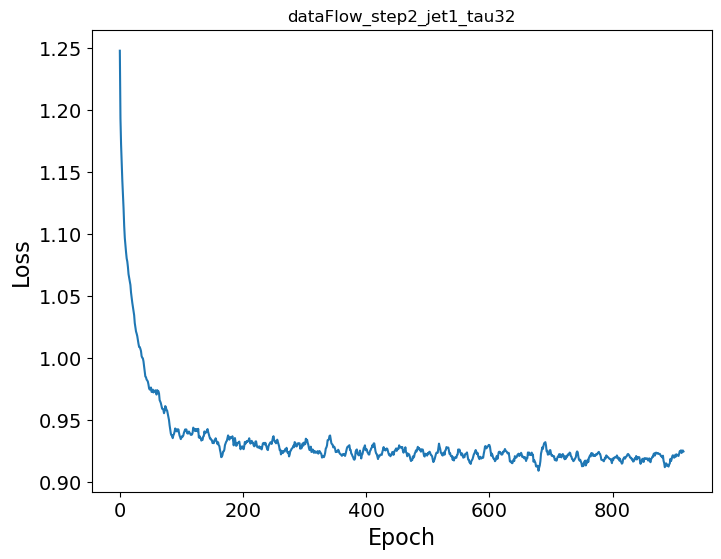

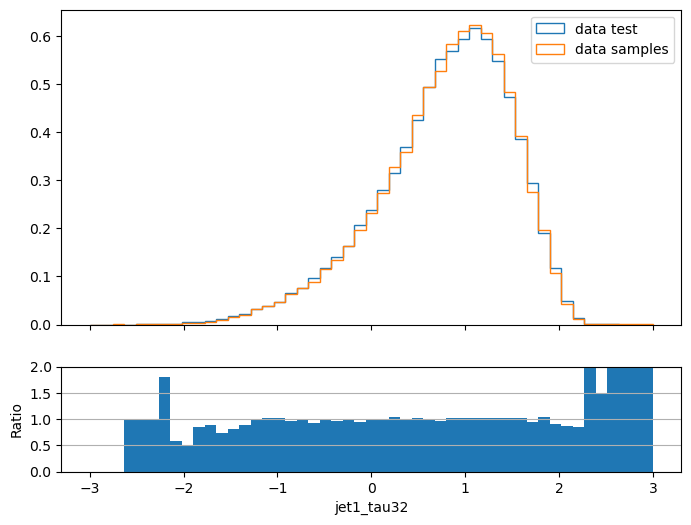

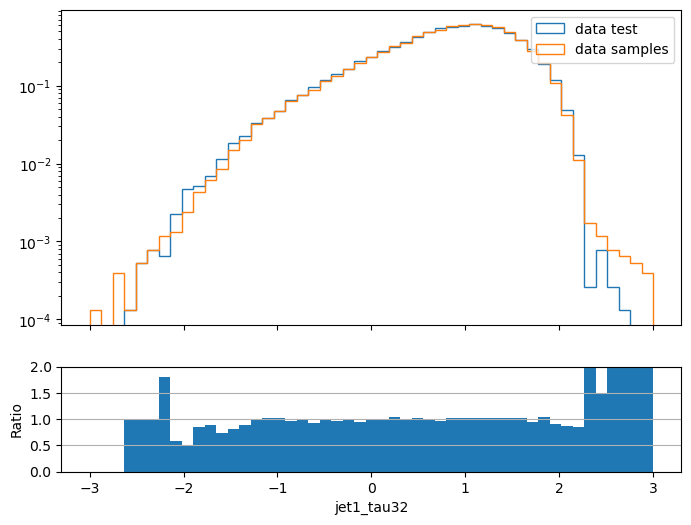

In [17]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 4096
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True,ylim=[0,2])

100%|██████████| 7/7 [00:00<00:00, 10.50it/s]


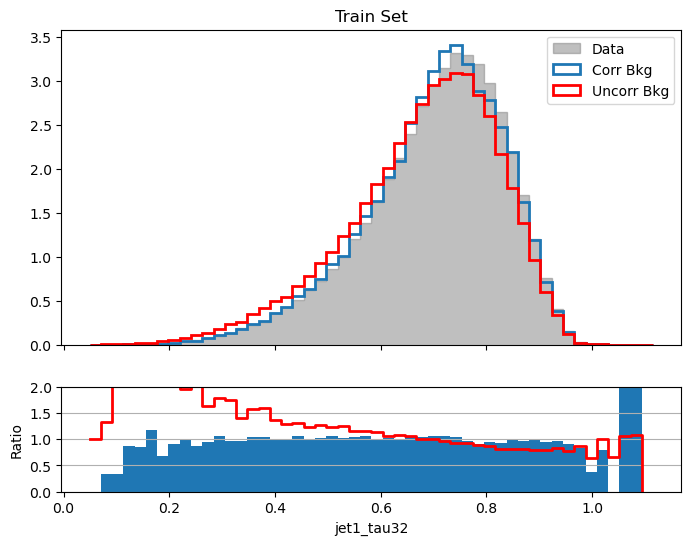

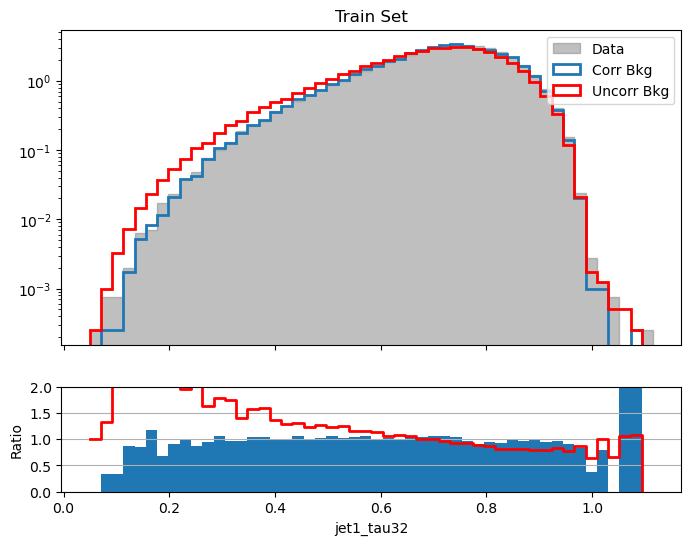

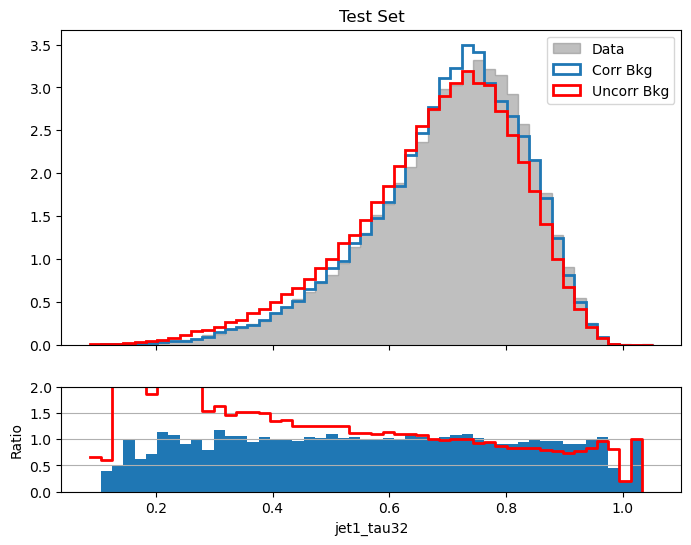

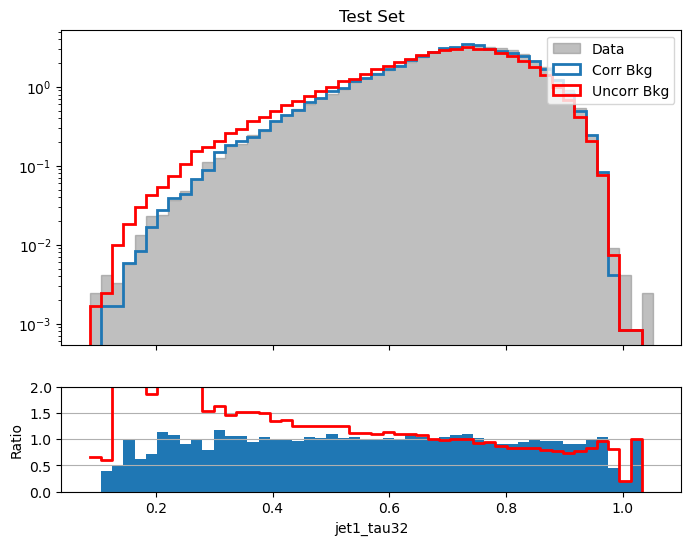

In [18]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [19]:
trainer.stepForward()

## jet1 tau43

Training flow bkgFlow_step3_jet1_tau43


Loss: 0.7244888758659362, p = 55: 100%|██████████| 374/374 [01:30<00:00,  4.12it/s]


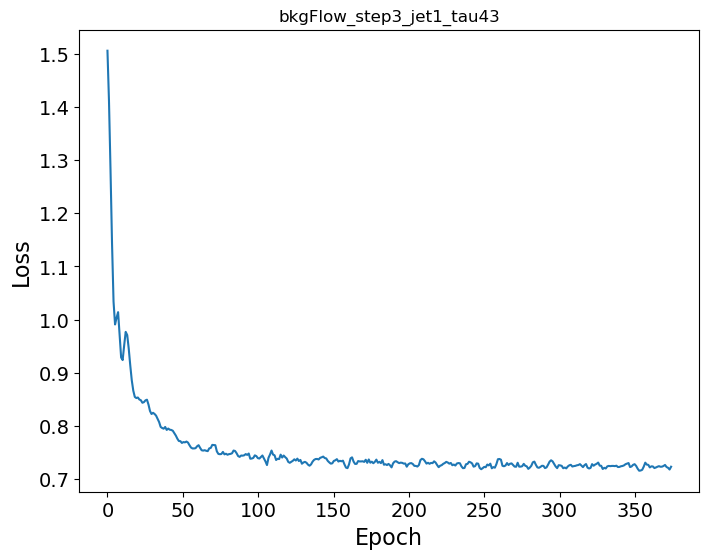

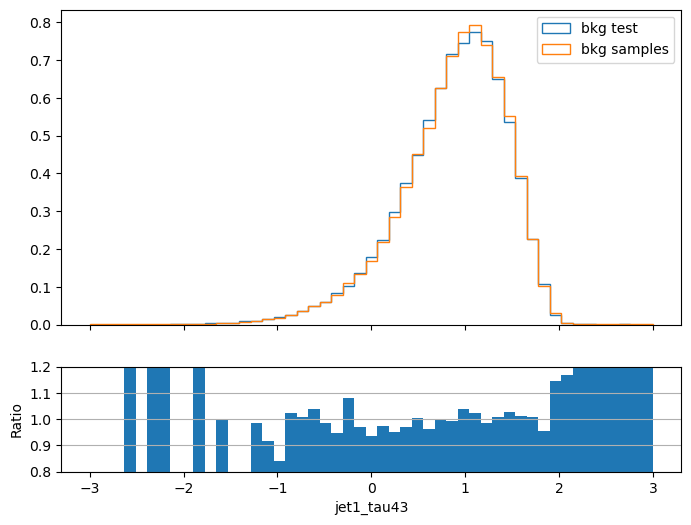

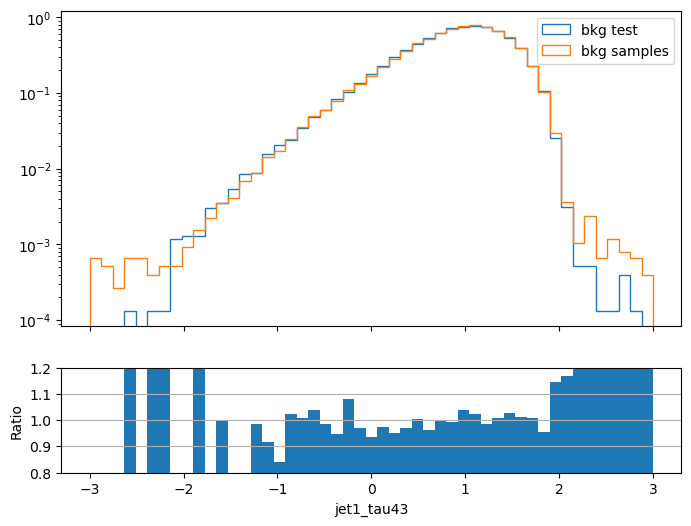

In [20]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step3_jet1_tau43


Loss: 0.6542495882511139, p = 9: 100%|██████████| 375/375 [01:30<00:00,  4.13it/s]  


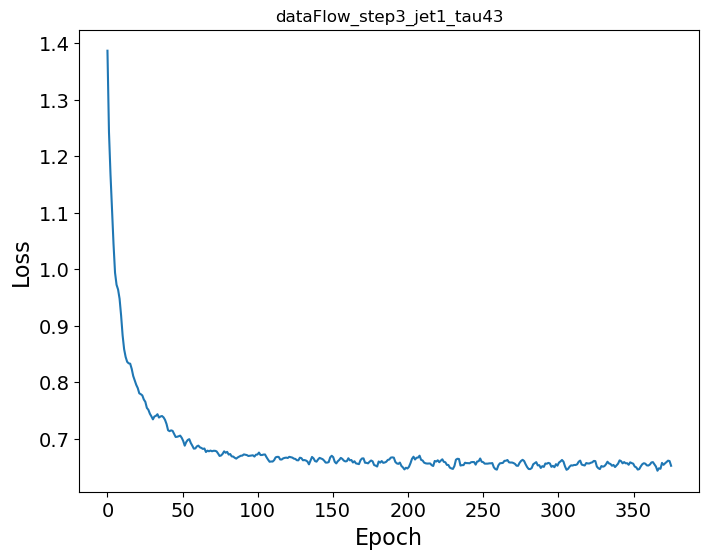

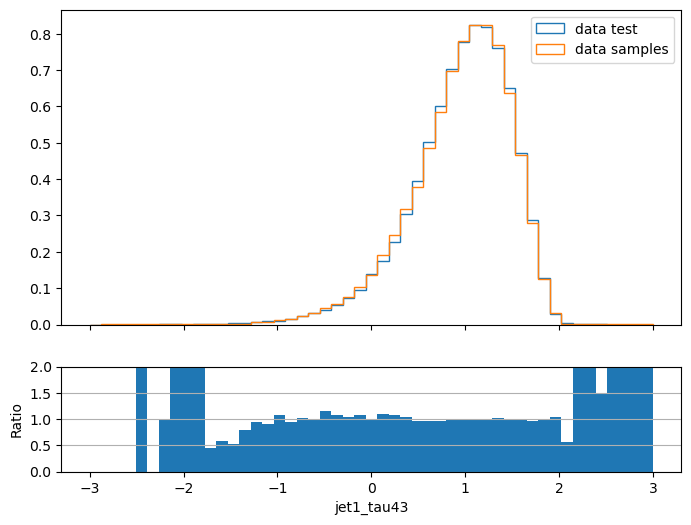

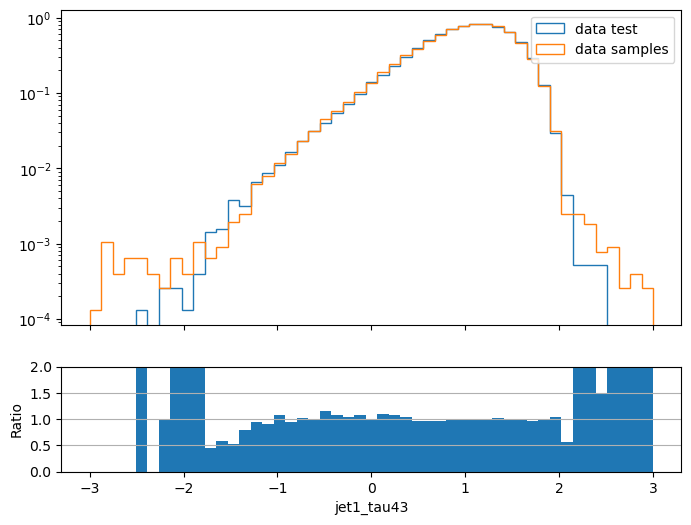

In [21]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True,ylim=[0,2])

100%|██████████| 7/7 [00:00<00:00, 10.53it/s]


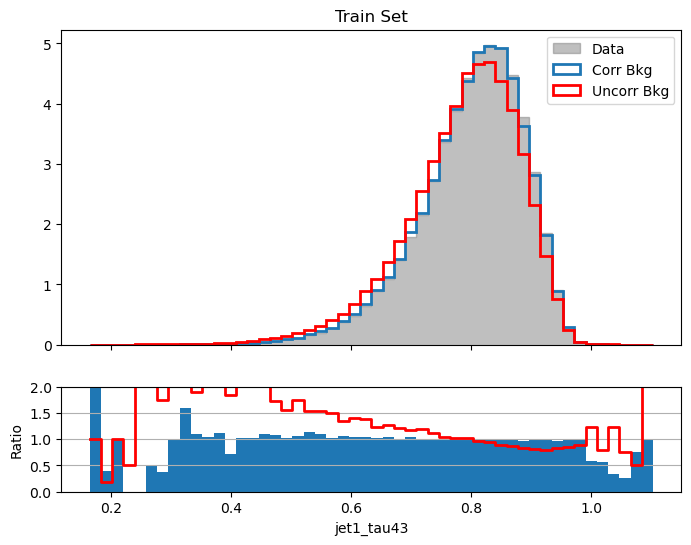

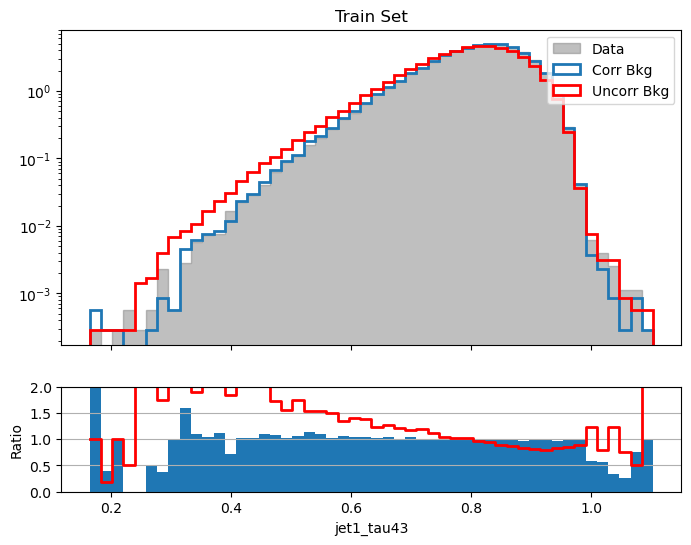

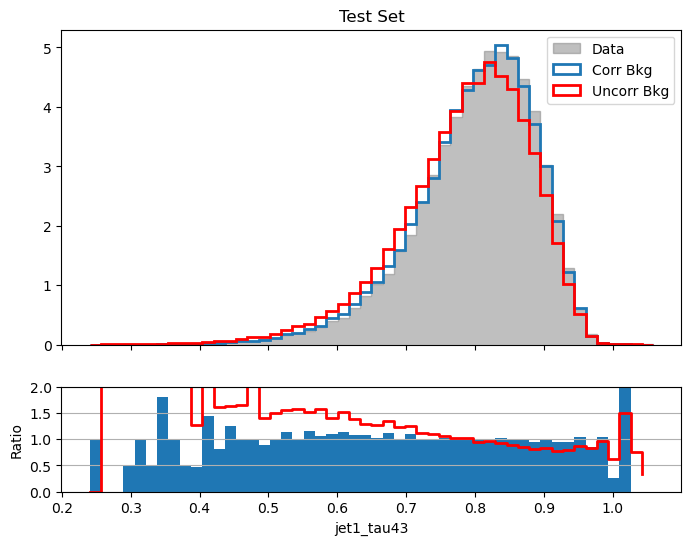

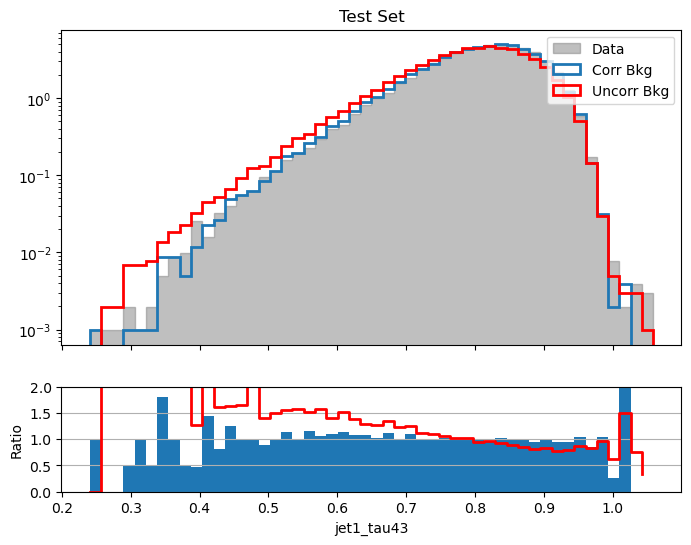

In [22]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [23]:
trainer.stepForward()

## jet1 pt

Training flow bkgFlow_step4_jet1_pt


Loss: 0.43102429240942003, p = 130: 100%|██████████| 374/374 [01:30<00:00,  4.14it/s]


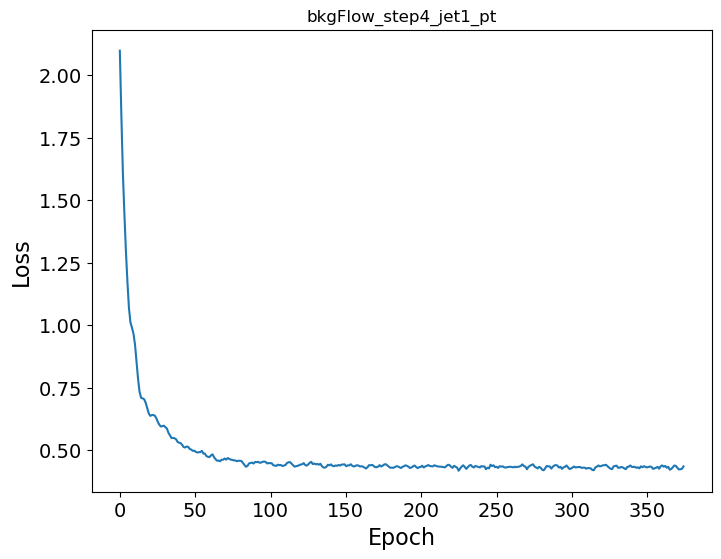

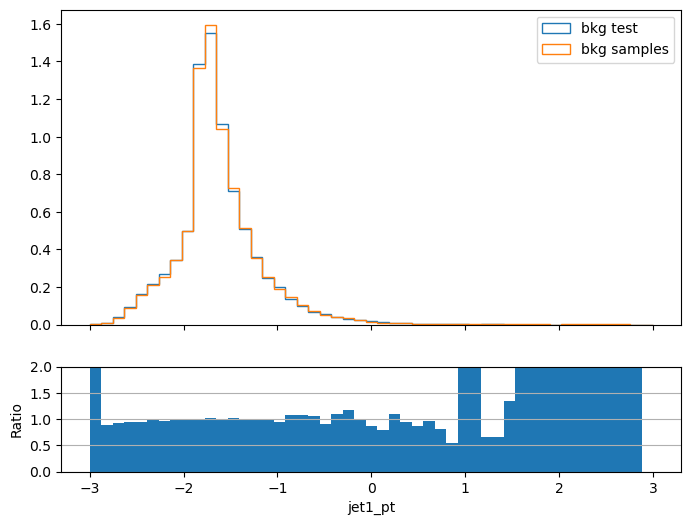

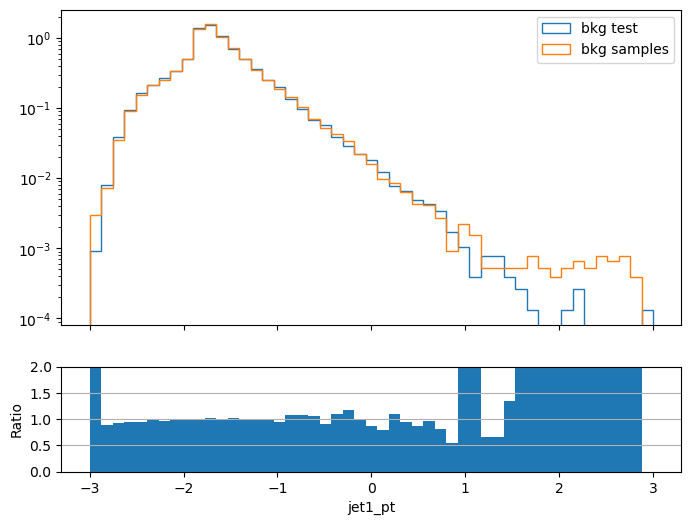

In [24]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True,ylim=[0,2])

Training flow dataFlow_step4_jet1_pt


Loss: 0.15983466148376466, p = 74: 100%|██████████| 375/375 [01:30<00:00,  4.16it/s]


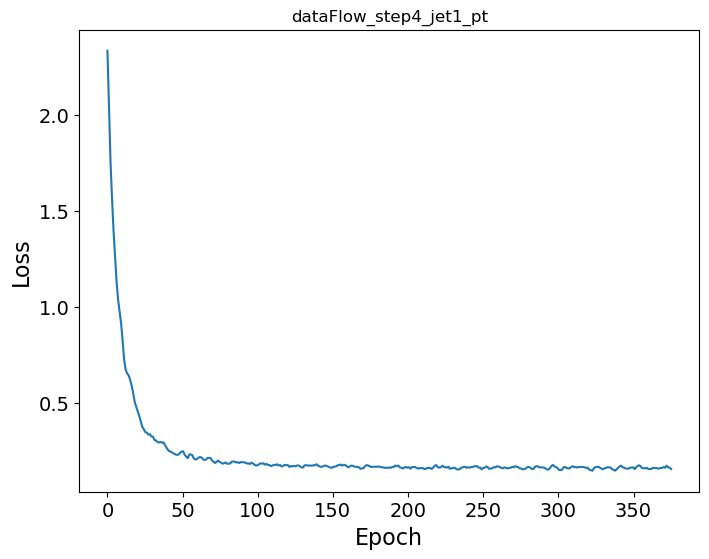

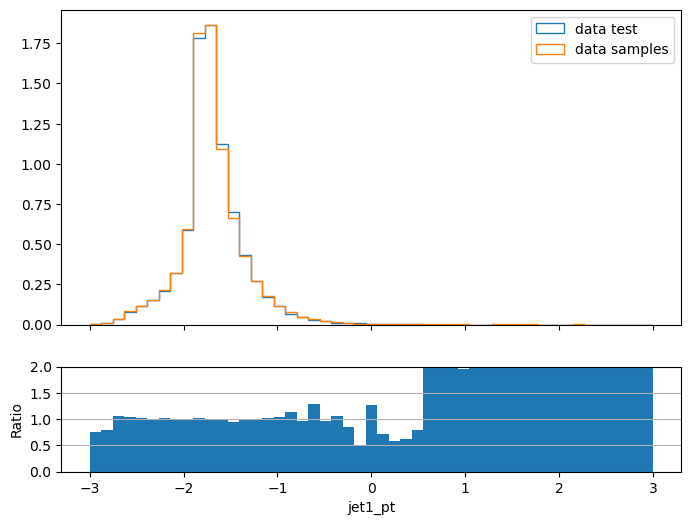

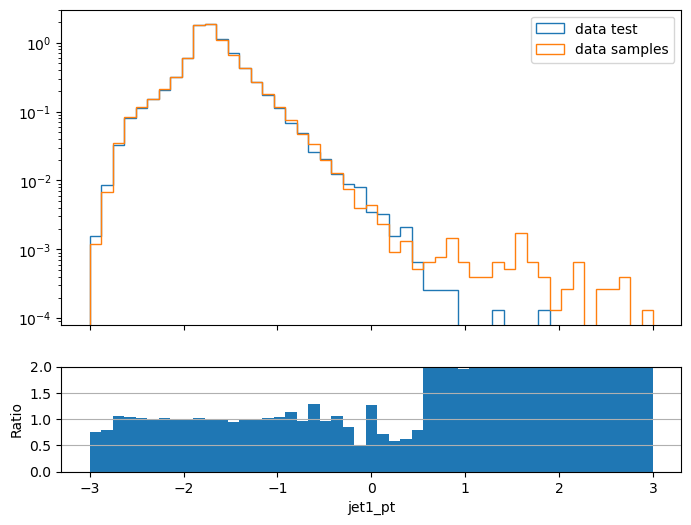

In [25]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True,ylim=[0,2])

100%|██████████| 7/7 [00:00<00:00, 12.14it/s]


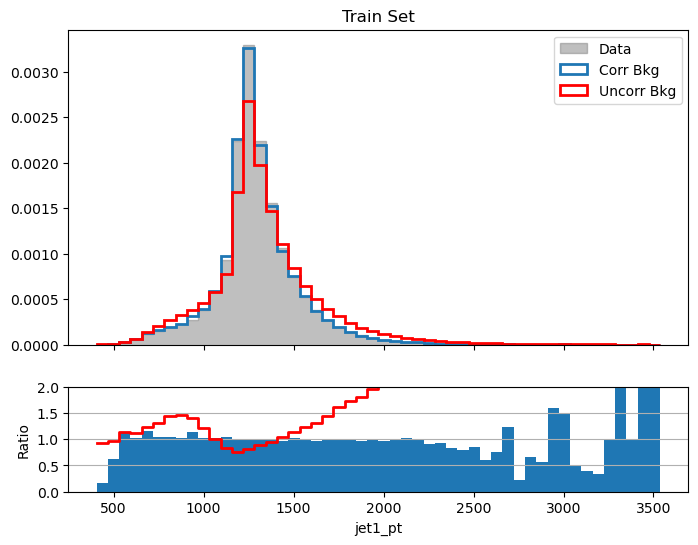

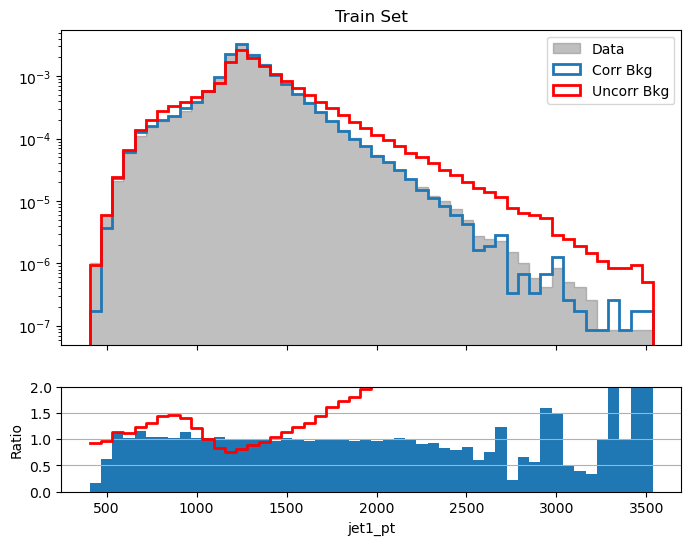

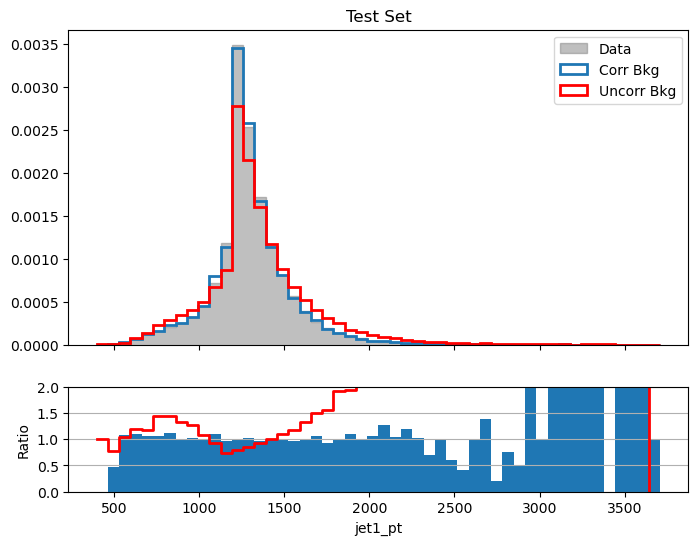

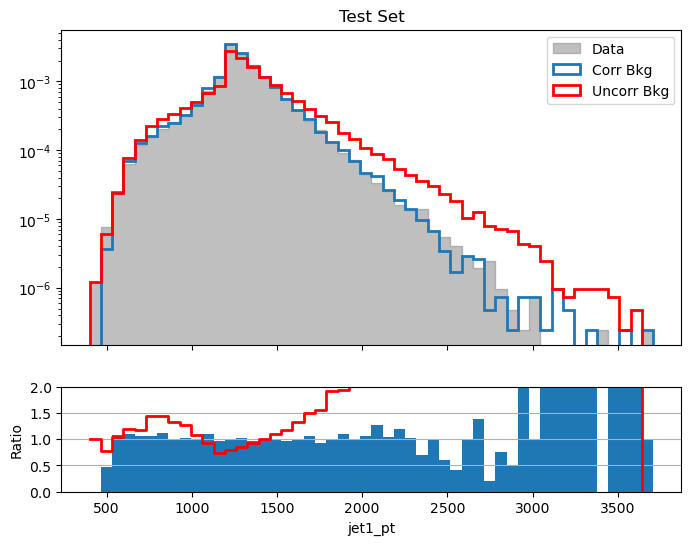

In [26]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [27]:
trainer.stepForward()

## jet2 eta

Training flow bkgFlow_step5_jet1_eta


Loss: 1.1292749011516572, p = 112: 100%|██████████| 374/374 [01:30<00:00,  4.15it/s]


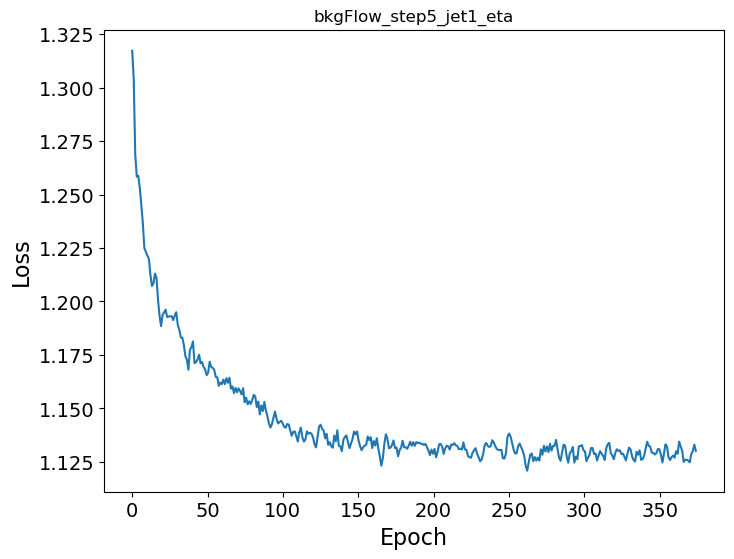

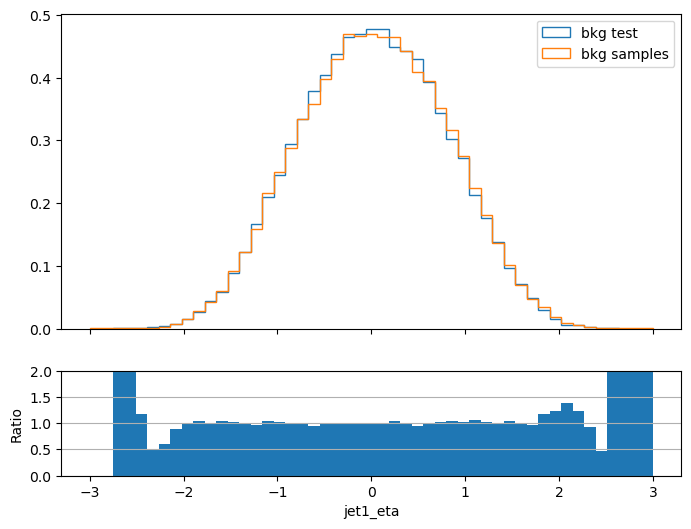

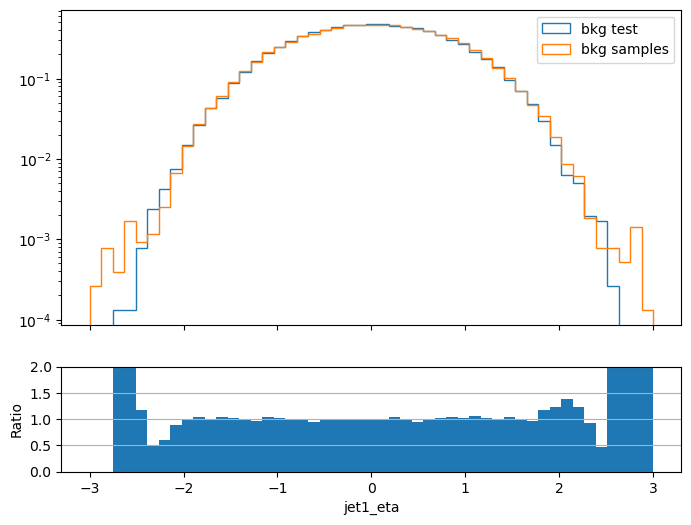

In [28]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True,ylim=[0,2])

Training flow dataFlow_step5_jet1_eta


Loss: 1.1518785917758942, p = 91: 100%|██████████| 375/375 [01:30<00:00,  4.16it/s]


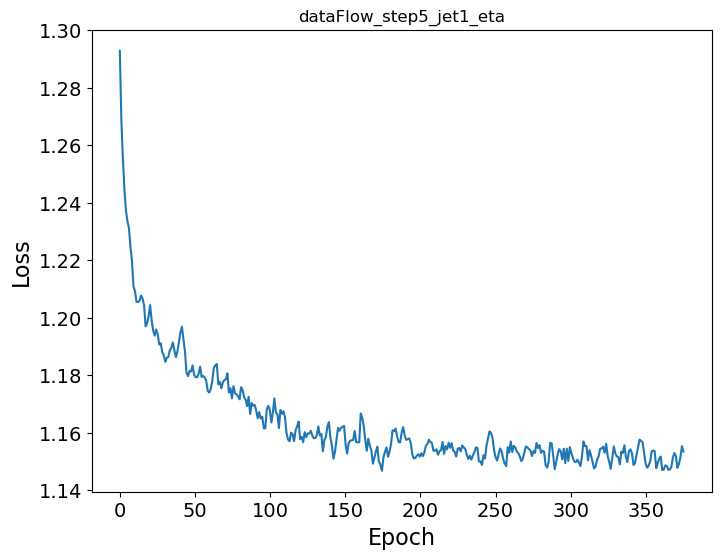

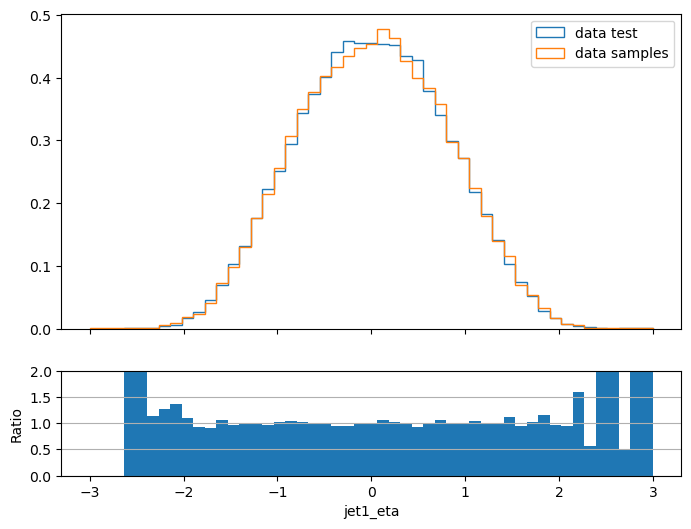

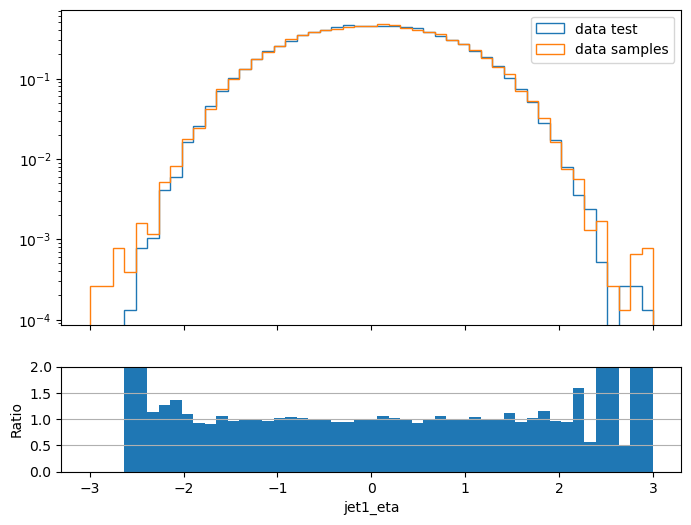

In [29]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True,ylim=[0,2])

100%|██████████| 7/7 [00:00<00:00, 12.26it/s]


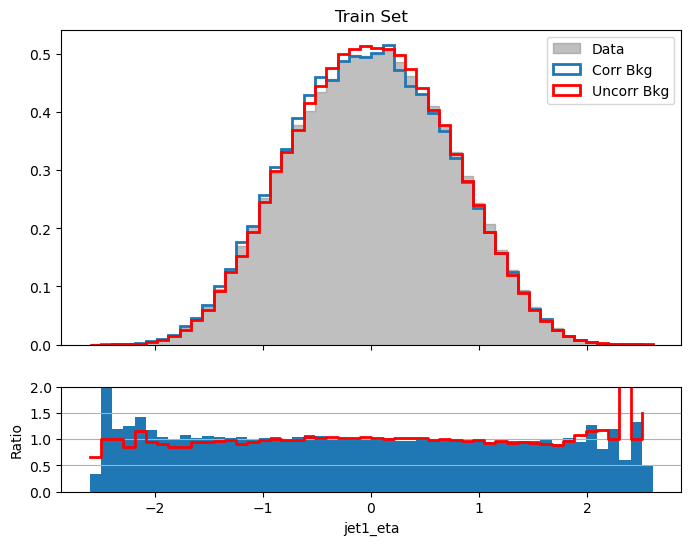

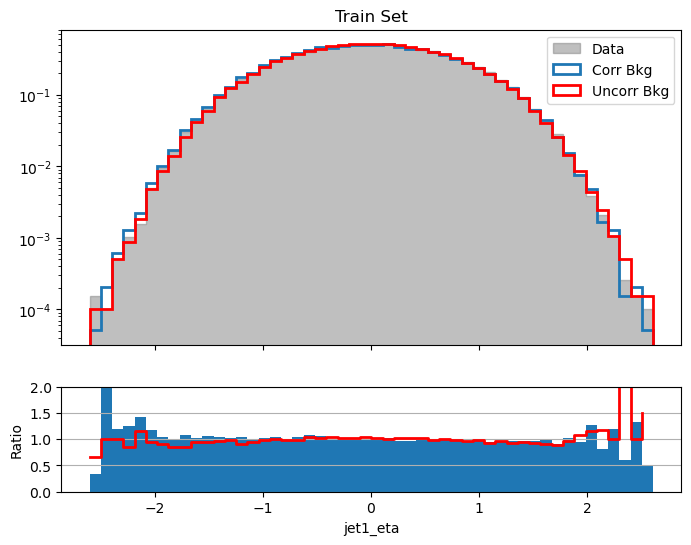

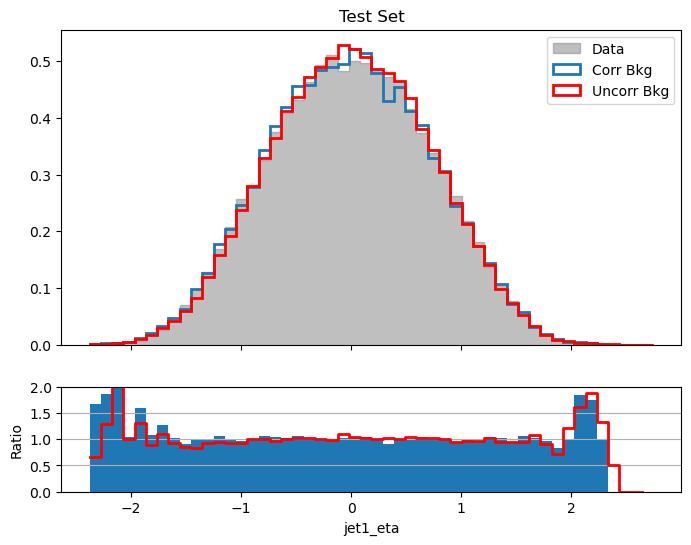

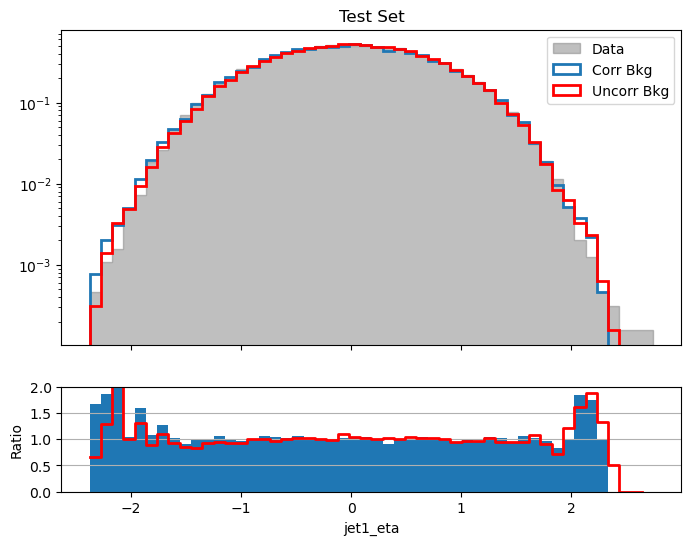

In [30]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [31]:
trainer.stepForward()

## jet1 phi

Training flow bkgFlow_step6_jet1_phi


Loss: 1.794930192232132, p = 31: 100%|██████████| 374/374 [01:33<00:00,  4.01it/s] 


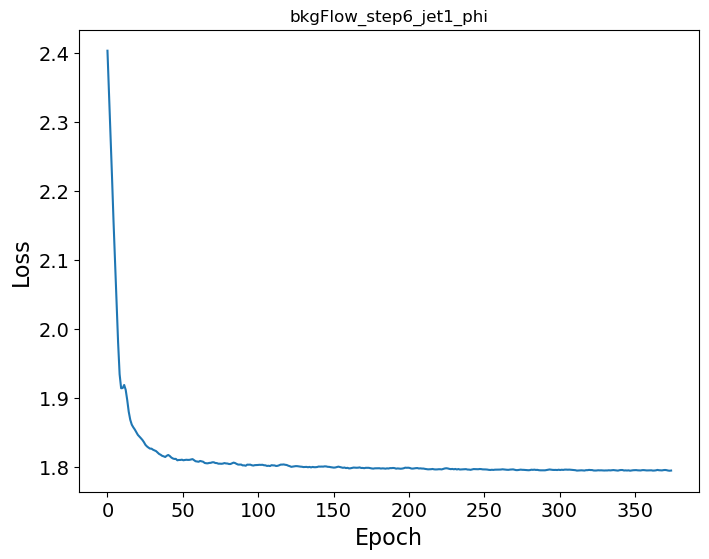

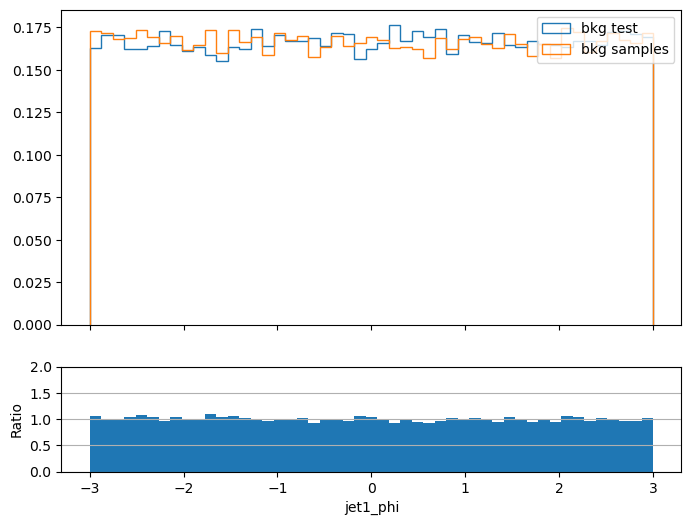

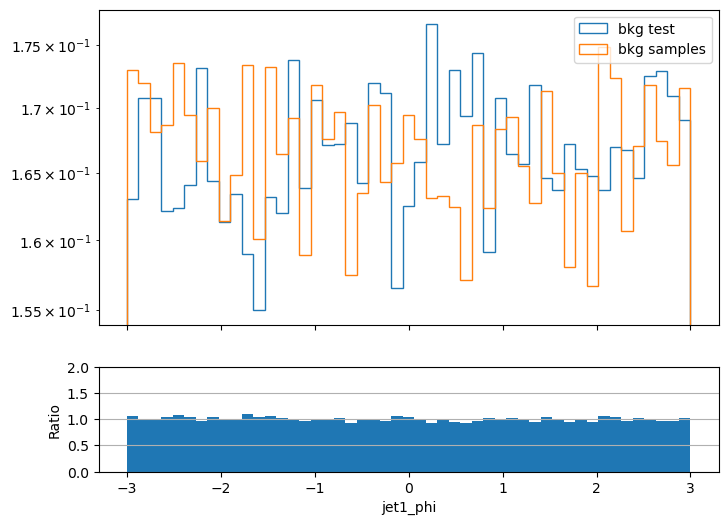

In [32]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True,ylim=[0,2])

In [ ]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True,ylim=[0,2])

Training flow dataFlow_step6_jet1_phi


Loss: 1.7962206733226775, p = 3:  74%|███████▍  | 277/375 [01:07<00:24,  3.99it/s] 

100%|██████████| 25/25 [00:02<00:00, 12.12it/s]


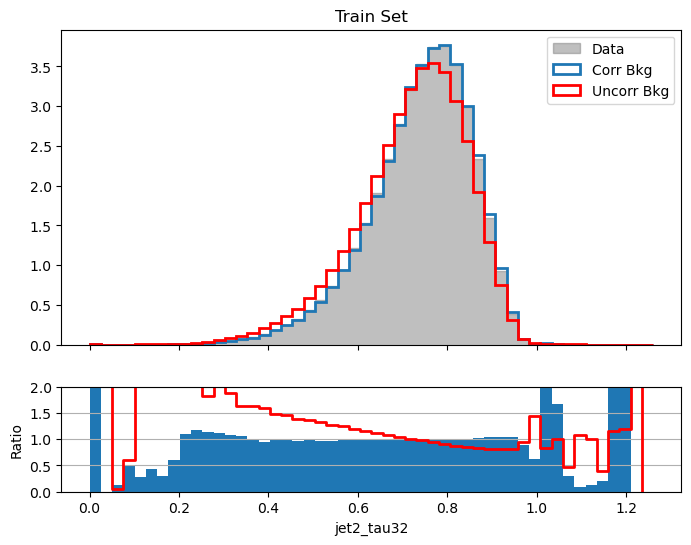

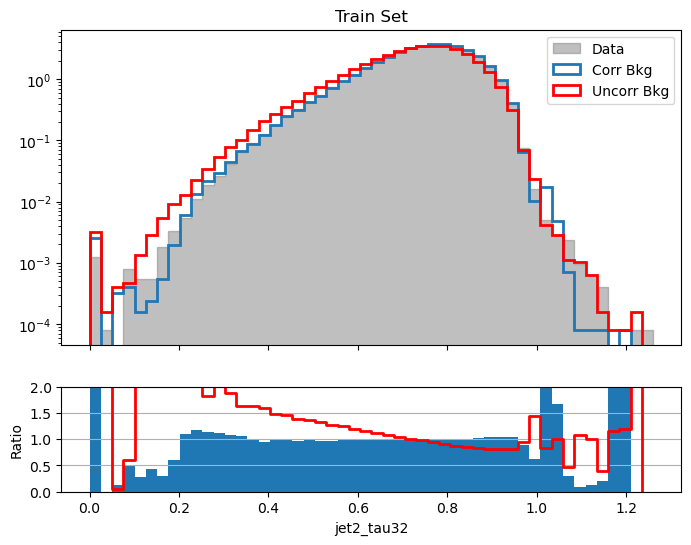

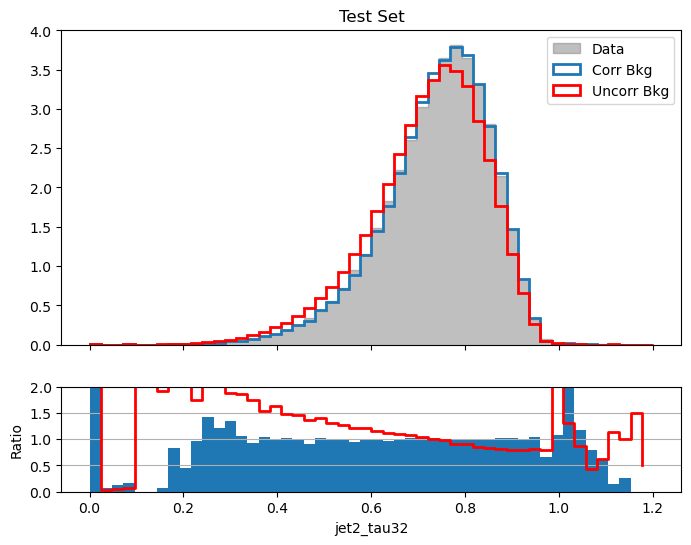

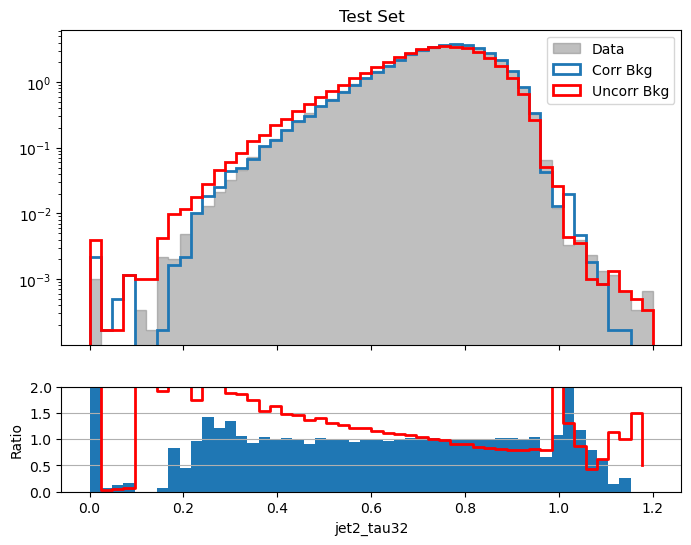

In [76]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [77]:
trainer.stepForward()

## jet1 pn score

Training flow bkgFlow_step7_pn_score


Loss: 0.28192194730043413, p = 2: 100%|██████████| 374/374 [01:30<00:00,  4.14it/s] 


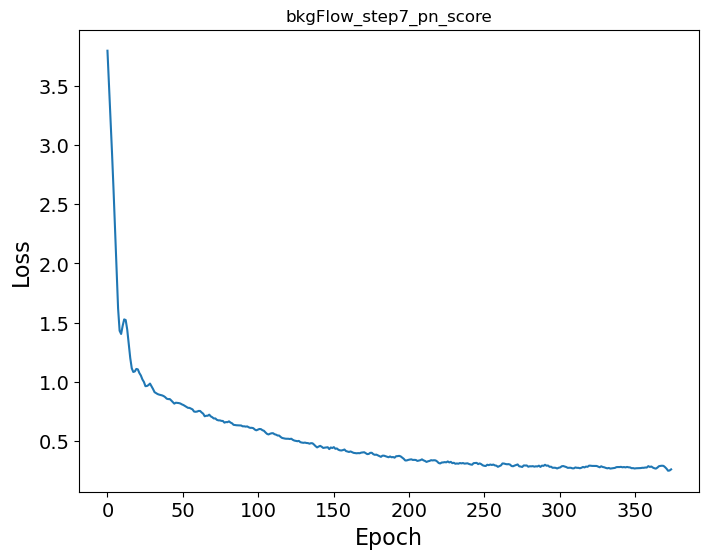

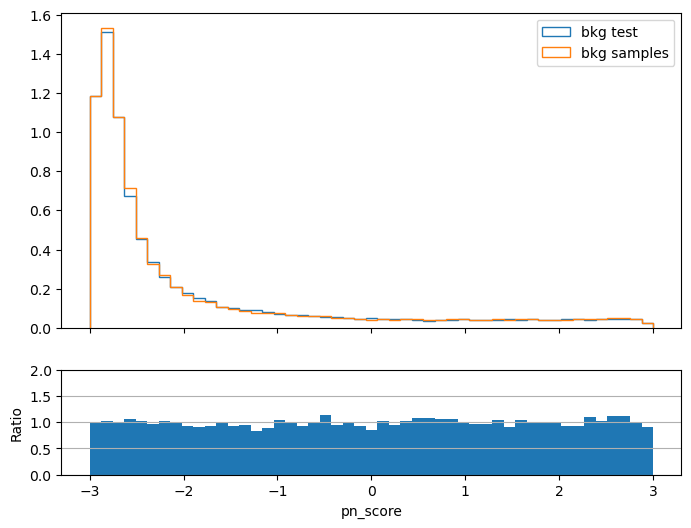

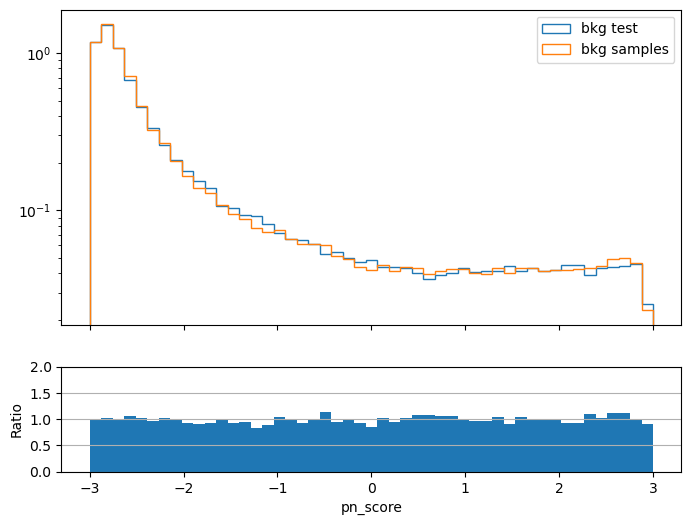

In [38]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True,ylim=[0,2])

Training flow dataFlow_step7_pn_score


Loss: -0.024334425057750197, p = 23: 100%|██████████| 375/375 [01:30<00:00,  4.14it/s]  


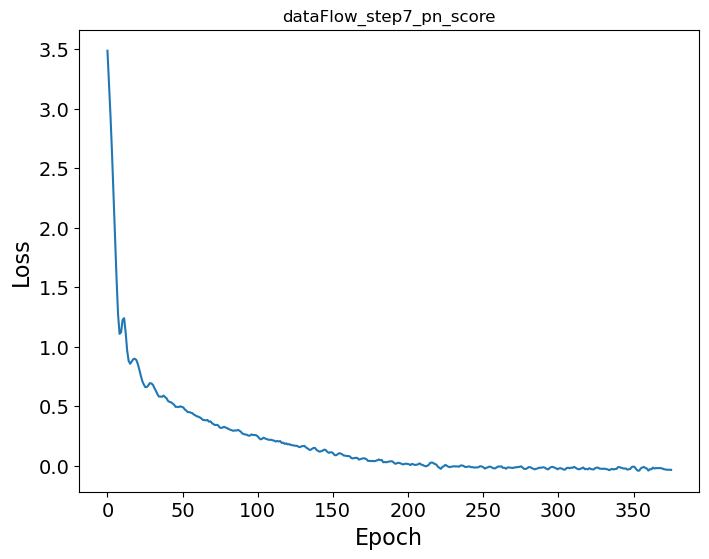

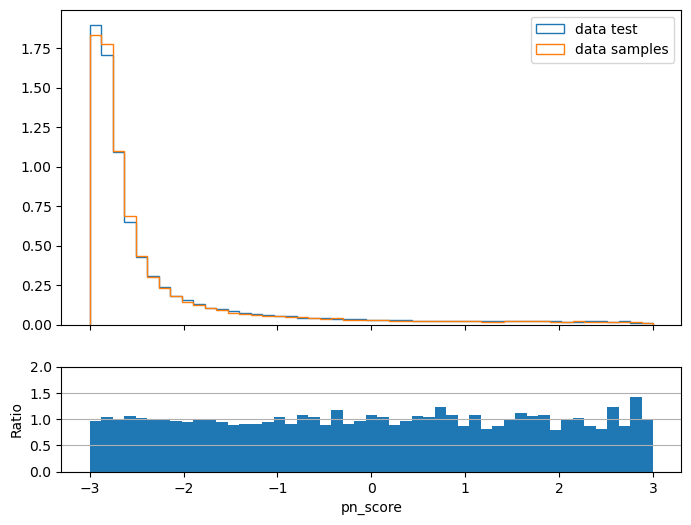

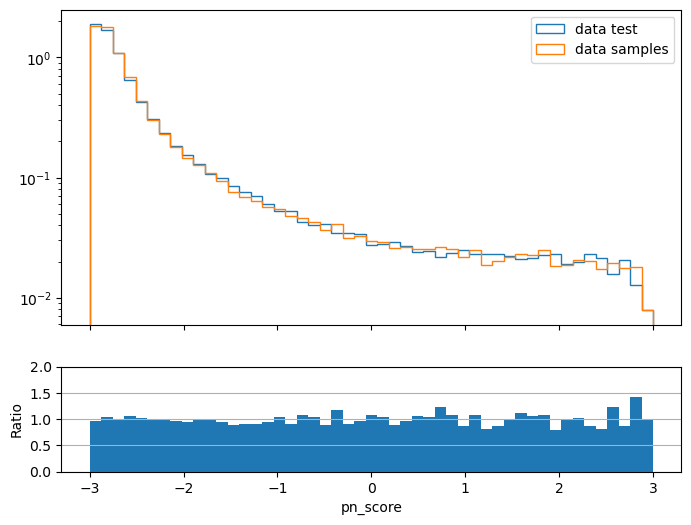

In [39]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True,ylim=[0,2])

In [ ]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

 29%|██▊       | 2/7 [00:00<00:00, 12.19it/s]